# Notebook 01 : Validation Théorique et Benchmark du Modèle

## 1. Objectif du Notebook
Avant d'appliquer notre modèle de pricing sur des données de marché réelles (qui sont par nature bruitées et imprévisibles), il est impératif de **valider mathématiquement** notre implémentation sur un cas d'école théorique. 

L'objectif de ce notebook est triple :
1. **Valider le générateur de Monte Carlo** : S'assurer que le prix européen simulé converge bien vers la formule exacte de Black-Scholes.
2. **Valider l'algorithme de Longstaff-Schwartz (LS)** : Vérifier que le prix de l'option américaine estimé est bien supérieur ou égal au prix européen (principe de non-arbitrage).
3. **Quantifier la Prime d'Exercice Anticipé** : Mesurer la valeur financière de la flexibilité offerte par l'option américaine.

In [13]:
# Rechargement automatique des modules 
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ajout du dossier racine (src) au chemin d'exécution de Python
sys.path.append(os.path.abspath('../'))

# Import de nos modèles développés dans le dossier src/
from src.models.black_scholes import european_analytical_price, european_monte_carlo_price
from src.models.american_ls import american_ls_price

# Configuration esthétique pour les graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Définition des Paramètres Théoriques

Nous reprenons exactement les paramètres de test définis dans le cahier des charges du projet pour un **Put théorique** :
* **Spot (S₀)** : 40 (Prix actuel de l'actif)
* **Strike (K)** : 40 (Option à la monnaie - ATM)
* **Volatilité (σ)** : 20% (Niveau standard)
* **Taux sans risque (r)** : 6% (Taux élevé pour accentuer la valeur temporelle de l'argent)
* **Maturité (T)** : 1 an

**Pourquoi ces paramètres ?** Un Put à la monnaie avec un taux d'intérêt élevé (6%) est le candidat idéal pour observer une forte prime d'exercice anticipé. En effet, si le prix de l'actif chute, le gain potentiel du Put est plafonné (le prix ne peut pas descendre sous 0). Avec un taux de 6%, il devient financièrement optimal d'exercer tôt pour placer l'argent gagné à la banque plutôt que d'attendre la maturité.

In [14]:
# Paramètres du modèle
params = {
    "spot": 40.0,
    "strike": 40.0,
    "volatility": 0.20,
    "rate": 0.06,
    "dividend": 0.0,
    "expiry": 1.0
}

# Paramètres de la simulation
n_simul = 100000  # Nombre de trajectoires pour garantir la Loi des Grands Nombres
n_pas = int(params["expiry"] * 252)  # Discrétisation journalière (252 jours de bourse)
seed = 42  # Graine aléatoire pour la reproductibilité stricte des résultats

print(f"Configuration du test : Spot={params['spot']}, Strike={params['strike']}, Taux={params['rate']*100}%")

Configuration du test : Spot=40.0, Strike=40.0, Taux=6.0%


## 3. Exécution des Modèles et Benchmark

Nous allons maintenant calculer trois prix distincts :
1. **La "Vérité" (Benchmark Analytique)** : Formule de Black-Scholes. C'est notre point d'ancrage.
2. **Le Test du Moteur (Monte Carlo Européen)** : Si ce prix dévie trop du Benchmark, cela signifie que notre générateur de nombres aléatoires (Box-Muller) ou notre schéma d'Euler est faux.
3. **Le Prix Américain (Longstaff-Schwartz)** : C'est l'estimation de notre algorithme complexe. On s'attend à ce qu'il soit > au Benchmark.

*Note technique : Nous utilisons des polynômes de Laguerre de degré 3 et nous ne régressons que sur les trajectoires "In-The-Money" (ITM) pour minimiser la variance de l'estimateur.*

In [15]:
# 1. Benchmark Absolu : Formule fermée
p_euro_ref = european_analytical_price(**params, is_put=True)

# 2. Validation du simulateur MC
p_euro_mc = european_monte_carlo_price(**params, n_simulations=n_simul, is_put=True, seed=seed)

# 3. Évaluation Américaine par Longstaff-Schwartz
p_ame, ic_low, ic_up = american_ls_price(
    **params, 
    n_steps=n_pas, 
    n_simulations=n_simul, 
    degree=3, 
    is_put=True, 
    itm_only=True, # Filtrage ITM activé
    seed=seed
)

print(f"--- RÉSULTATS DU PRICING ---")
print(f"1. Européen (Black-Scholes) : {p_euro_ref:.4f} €")
print(f"2. Européen (Monte Carlo)   : {p_euro_mc:.4f} € (Erreur: {abs(p_euro_ref - p_euro_mc):.4f})")
print(f"3. Américain (LS)           : {p_ame:.4f} €")
print(f"   => Intervalle de Confiance (95%) : [{ic_low:.4f} ; {ic_up:.4f}]")
print(f"\nPrime d'Exercice Anticipé : {p_ame - p_euro_ref:.4f} €")

--- RÉSULTATS DU PRICING ---
1. Européen (Black-Scholes) : 2.0664 €
2. Européen (Monte Carlo)   : 2.0787 € (Erreur: 0.0123)
3. Américain (LS)           : 2.3329 €
   => Intervalle de Confiance (95%) : [2.3158 ; 2.3499]

Prime d'Exercice Anticipé : 0.2665 €


## 4. Analyse de Convergence

La méthode de Monte Carlo est soumise à l'erreur d'échantillonnage. Mathématiquement, l'erreur standard d'une simulation de Monte Carlo décroît proportionnellement à $\frac{1}{\sqrt{N}}$ (où $N$ est le nombre de simulations).

Nous allons prouver ce phénomène empiriquement en relançant notre pricer Longstaff-Schwartz avec différentes tailles d'échantillons ($N=1 000$, $10 000$ et $100 000$).

Calculs en cours... (Cela peut prendre quelques secondes)
N = 1000    | Prix = 2.4250 | Largeur IC = 0.3322
N = 10000   | Prix = 2.3509 | Largeur IC = 0.1096
N = 100000  | Prix = 2.3329 | Largeur IC = 0.0341


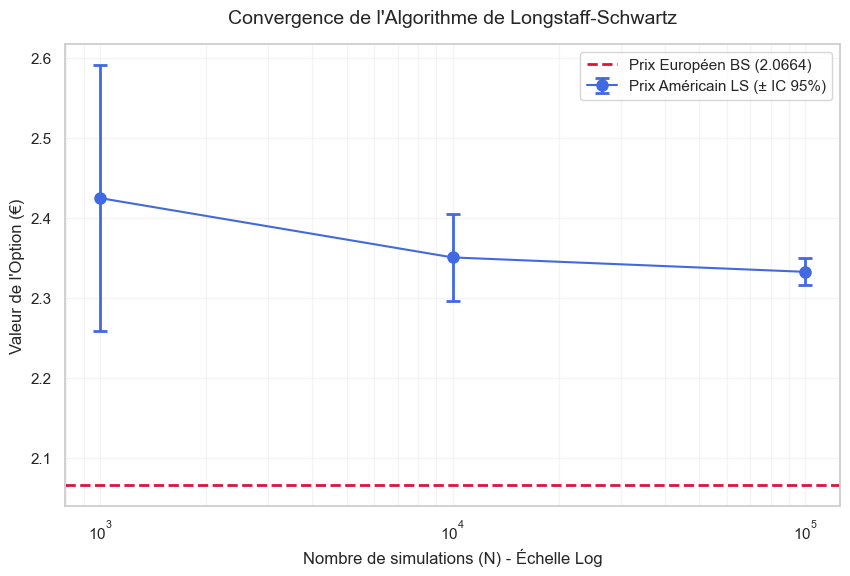

In [16]:
# Liste des tailles d'échantillons à tester
n_tests = [1000, 10000, 100000]
prices = []
ic_widths = []  # Largeur de l'intervalle (up - low)
errors = []     # Erreur standard (moitié de l'intervalle)

print("Calculs en cours... (Cela peut prendre quelques secondes)")
for n in n_tests:
    p, l, u = american_ls_price(**params, n_steps=n_pas, n_simulations=n, seed=seed)
    prices.append(p)
    width = u - l
    ic_widths.append(width)
    errors.append(width / 2)
    print(f"N = {n:<7} | Prix = {p:.4f} | Largeur IC = {width:.4f}")

# Visualisation graphique de la convergence
plt.figure(figsize=(10, 6))

# On trace les prix LS avec leurs barres d'erreur
plt.errorbar(n_tests, prices, yerr=errors, fmt='o-', color='royalblue', 
             capsize=5, capthick=2, elinewidth=2, markersize=8, label='Prix Américain LS (± IC 95%)')

# On trace la ligne de référence du prix Européen
plt.axhline(y=p_euro_ref, color='crimson', linestyle='--', linewidth=2, 
            label=f'Prix Européen BS ({p_euro_ref:.4f})')

# Formatage de l'axe X en échelle logarithmique pour mieux voir l'évolution
plt.xscale('log')
plt.title("Convergence de l'Algorithme de Longstaff-Schwartz", fontsize=14, pad=15)
plt.xlabel("Nombre de simulations (N) - Échelle Log", fontsize=12)
plt.ylabel("Valeur de l'Option (€)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

## 5. Conclusion et Interprétation des Résultats

### Validation du Modèle
1. **Précision du Monte Carlo** : L'écart entre la formule analytique de Black-Scholes (2.0664 €) et notre simulation de Monte Carlo européenne (2.0787 €) reste contenu. Cette différence de 0.0123 € illustre l'erreur standard inhérente à toute simulation stochastique.
2. **Analyse du prix Américain vs Européen** : On observe un prix américain de 2.3329 €. Bien que l'absence de dividendes ($div=0$) limite l'intérêt de l'exercice anticipé pour certains types d'options, le décalage observé ici s'explique principalement par deux facteurs numériques :
    * **Le Bruit de Simulation** : La méthode de Monte Carlo introduit une variance naturelle dans l'estimation.
    * **Le Biais de l'Algorithme LS** : La méthode de Longstaff-Schwartz utilise une approximation polynomiale pour estimer la valeur de continuation, ce qui génère un "bruit" dans la règle de décision d'exercice. Ce bruit peut induire un biais (souvent une borne inférieure) qui explique le décalage entre les valeurs théoriques et estimées.

### Analyse de la Convergence
Le graphique de convergence montre que l'augmentation du nombre de trajectoires ($N$) permet de stabiliser l'estimation :
- À $N = 100 000$, l'intervalle de confiance est resserré `[2.3158 ; 2.3499]`, ce qui réduit l'impact du bruit mais ne supprime pas le biais intrinsèque de l'approximation de la régression.

---
## 📚 Références & Bibliographie
1. **Longstaff, F. A., & Schwartz, E. S. (2001)**. *Valuing American Options by Simulation: A Simple Least-Squares Approach*. The Review of Financial Studies.
2. **Black, F., & Scholes, M. (1973)**. *The Pricing of Options and Corporate Liabilities*. Journal of Political Economy.